In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification
from sklearn.metrics.pairwise import cosine_similarity
from Bio import pairwise2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
external_files = [
    r"D:\7D12\7D12\7D12_cdr_fixed.csv",
    r"D:\7D12\9G8\9G8_cdr_fixed.csv",
    r"D:\7D12\EgA1\EgA1_cdr_fixed.csv",
    r"D:\7D12\EgB4\EgB4_cdr_fixed.csv",
    r"D:\7D12\4G3\4G3_cdr_fixed.csv",
]

external_list = []
for file in external_files:
    df = pd.read_csv(file)
    binder_name = Path(file).stem.replace("_cdr_fixed", "")
    if binder_name == "4G3":
        binder_type = "Synthetic EGFR binder"
    else:
        binder_type = "Immune EGFR binder"

    external_list.append({
        "Binder_name": binder_name,
        "Binder_type": binder_type,
        "Sequence": df["Sequence"].iloc[0],
        "CDR1 aligned": df["CDR1 aligned"].iloc[0],
        "CDR2 aligned": df["CDR2 aligned"].iloc[0],
        "CDR3 aligned": df["CDR3 aligned"].iloc[0],
        "Label": 1,
        "Split": "External"
    })

external_df = pd.DataFrame(external_list)
print(external_df[["Binder_name", "Binder_type"]])

  Binder_name            Binder_type
0        7D12     Immune EGFR binder
1         9G8     Immune EGFR binder
2        EgA1     Immune EGFR binder
3        EgB4     Immune EGFR binder
4         4G3  Synthetic EGFR binder


In [3]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_validation.csv")
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")

seq_col = "Sequence"
label_col = "Label"
num_labels = 2

In [ ]:
MODEL = "NaturalAntibody/nanoBERT"
best_path = r"D:\7D12\best_nanobert_finetuned_weighted_70.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
config = AutoConfig.from_pretrained(MODEL)
config.num_labels = num_labels

nanobert_model = AutoModelForSequenceClassification.from_config(config)

state = torch.load(best_path, map_location=device)
nanobert_model.load_state_dict(state)

nanobert_model.to(device)
nanobert_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(25, 320, padding_idx=1)
      (token_type_embeddings): Embedding(1, 320)
      (LayerNorm): LayerNorm((320,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(202, 320, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
       

In [5]:
train_sample = train_df.sample(min(3000, len(train_df)), random_state=42)
val_sample = val_df.sample(min(1000, len(val_df)), random_state=42)
test_sample = test_df.sample(min(1000, len(test_df)), random_state=42)

external_df = external_df.copy()
external_df["Label"] = 1

In [ ]:
train_pos = train_df[train_df["Label"] == 1].copy()
test_pos = test_df[test_df["Label"] == 1].copy()

train_pos = train_pos.sample(
    min(2000, len(train_pos)),
    random_state=42
)
test_pos = test_pos.sample(
    min(1000, len(test_pos)),
    random_state=42
)

train_pos["group"] = "Train positive"
test_pos["group"] = "Test positive"
external_plot = external_df.copy()
external_plot["group"] = external_plot["Binder_type"]

plot_df = pd.concat(
    [train_pos, test_pos, external_plot],
    ignore_index=True
).reset_index(drop=True)

print(plot_df["group"].value_counts())


group
Train positive           2000
Test positive            1000
Immune EGFR binder          4
Synthetic EGFR binder       1
Name: count, dtype: int64


In [7]:
required_cols = [
    "Sequence",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned"
]

missing = plot_df[required_cols].isna().sum()
assert missing.sum() == 0, f"Missing sequence data:\n{missing}"

valid_aa = set("ACDEFGHIKLMNPQRSTVWY-")

for col in required_cols:
    invalid = set("".join(plot_df[col].astype(str))) - valid_aa
    assert not invalid, f"Invalid characters in {col}: {invalid}"

In [ ]:
def extract_nanobert_embeddings(sequences, tokenizer, model, batch_size=16):
    model = model.to(DEVICE)
    model.eval()
    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(sequences), batch_size)):
            batch = sequences[i:i + batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True
            )

            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            outputs = model(
                **inputs,
                output_hidden_states=True
            )

            last_hidden = outputs.hidden_states[-1]
            cls_embedding = last_hidden[:, 0, :]
            embeddings.append(cls_embedding.cpu().numpy())

    return np.vstack(embeddings)

In [9]:
X_nanobert = extract_nanobert_embeddings(
    plot_df[seq_col].astype(str).tolist(),
    tokenizer,
    nanobert_model,
    batch_size=16
)

100%|██████████| 188/188 [01:14<00:00,  2.53it/s]


In [ ]:
seq_cols = ["CDR1 aligned", "CDR2 aligned", "CDR3 aligned"]
amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
add_position = True
def concat_cdrs(row):
    return "".join(str(row[col]) for col in seq_cols)

aa2idx = {aa: i for i, aa in enumerate(amino_acids)}
I = np.eye(len(amino_acids),dtype=np.float32) 
def one_hot_encode(seq, add_position=True):
    feats = []
    L = len(seq)
    for i, a in enumerate(seq):
        v = I[aa2idx.get(a, aa2idx["-"])]
        if add_position:
            v = np.concatenate((v, [i / L]))
        feats.append(v)
    return np.array(feats, dtype=np.float32)  


In [ ]:
class ProteinCNN(nn.Module):
    def __init__(
        self,
        input_dim=22,
        num_classes=2,
        num_blocks=3,
        base_ch=64,
        kernel_size=7,
        dropout=0.3,
        hidden_dim=128
    ):
        super().__init__()
        layers = []
        in_ch = input_dim
        padding = kernel_size // 2
        channel_sizes = [base_ch * (2 ** i) for i in range(num_blocks)]

        for out_ch in channel_sizes:
            layers.append(nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding))
            layers.append(nn.BatchNorm1d(out_ch))
            layers.append(nn.ReLU())
            in_ch = out_ch

        self.conv = nn.Sequential(*layers)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(channel_sizes[-1], hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward_features(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return F.relu(self.fc1(x))

    def forward(self, x):
        return self.fc2(self.forward_features(x))

In [12]:

cnn_model_path = r"D:\7D12\best_cdrs_cnn_optuna_final_trainval_70.pth"
cnn_model = ProteinCNN(
    input_dim=22,
    num_classes=2,
    base_ch=96,        
    num_blocks=3,     
    kernel_size=15,   
    dropout=0.4862528132298237,     
    hidden_dim=64      
)

state = torch.load(cnn_model_path, map_location=device)
cnn_model.load_state_dict(state)
cnn_model = cnn_model.to(device)
cnn_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
def extract_cnn_latent_representations(encoded_sequences, cnn_model, batch_size=32):
    cnn_model = cnn_model.to(DEVICE)
    cnn_model.eval()
    features_all = []

    with torch.no_grad():
        for i in tqdm(range(0, len(encoded_sequences), batch_size)):
            batch = encoded_sequences[i:i + batch_size]
            batch = torch.tensor(batch, dtype=torch.float32).to(DEVICE)
            features = cnn_model.forward_features(batch)

            features_all.append(features.cpu().numpy())

    return np.vstack(features_all)

In [ ]:
plot_df["CDRs"] = plot_df.apply(concat_cdrs, axis=1)

lengths = plot_df["CDRs"].str.len()
assert lengths.nunique() == 1, (
    f"CNN input lengths differ: {sorted(lengths.unique())}")

encoded_sequences = np.stack([
    one_hot_encode(sequence, add_position=True)
    for sequence in plot_df["CDRs"]])

X_cnn = extract_cnn_latent_representations(
    encoded_sequences,
    cnn_model,
    batch_size=32)

print("CNN feature shape:", X_cnn.shape)

100%|██████████| 94/94 [00:04<00:00, 22.38it/s]

CNN feature shape: (3005, 64)


In [ ]:
def run_and_plot_umap(X, plot_df, title, save_name):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42)

    coords = reducer.fit_transform(X)

    df = plot_df.copy()
    df["UMAP1"] = coords[:, 0]
    df["UMAP2"] = coords[:, 1]

    plt.figure(figsize=(9, 7))

    for group in df["group"].unique():
        subset = df[df["group"] == group]
        if group in ["Immune EGFR binder", "Synthetic EGFR binder"]:
            plt.scatter(subset["UMAP1"], subset["UMAP2"], s=160, marker="X", label=group)
        elif group == "Test positive":
            plt.scatter(subset["UMAP1"], subset["UMAP2"], s=25, alpha=0.5, label=group)
        else:
            plt.scatter(subset["UMAP1"], subset["UMAP2"], s=20, alpha=0.3, label=group)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()
    return df

d:\nanobody_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


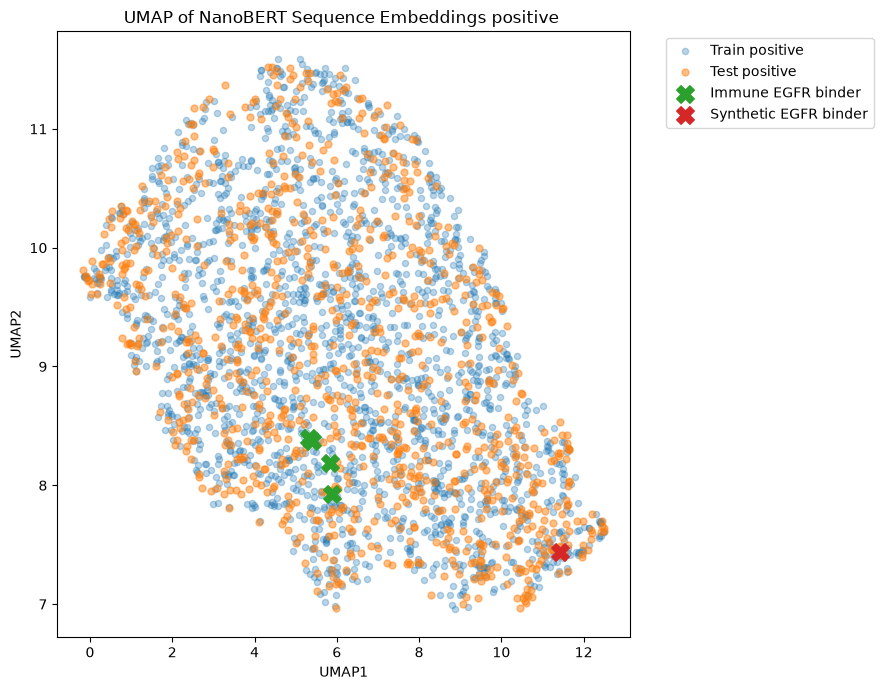

In [16]:
nanobert_umap_df = run_and_plot_umap(
    X_nanobert,
    plot_df,
    "UMAP of NanoBERT Sequence Embeddings positive ",
    "nanobert_umap_external_egfr positive.png"
)

nanobert_umap_df.to_csv("nanobert_umap_coordinates positive.csv", index=False)

d:\nanobody_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


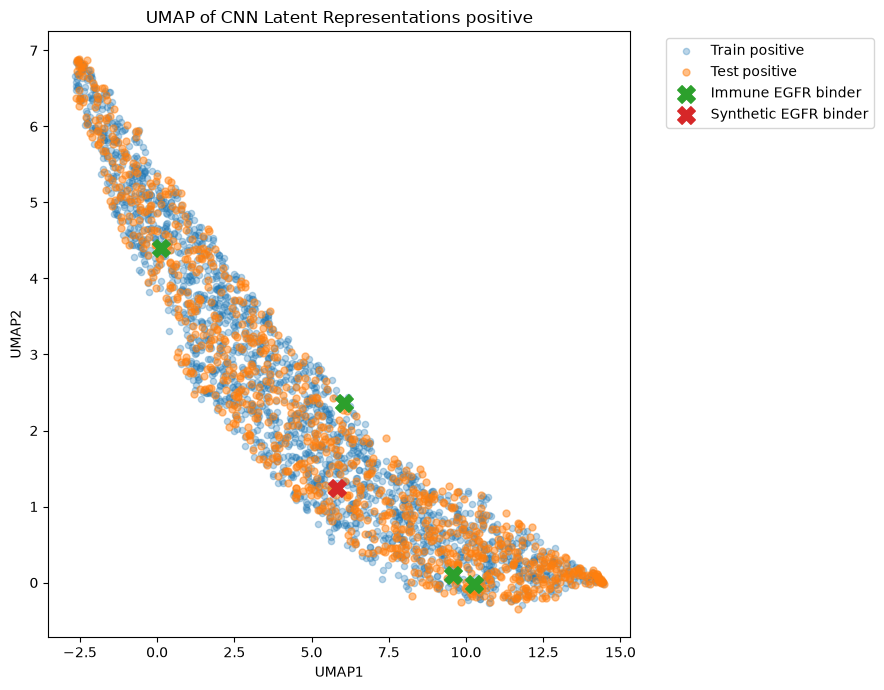

In [17]:
cnn_umap_df = run_and_plot_umap(
    X_cnn,
    plot_df,
    "UMAP of CNN Latent Representations positive",
    "cnn_umap_external_egfr positive.png"
)

cnn_umap_df.to_csv("cnn_umap_coordinates positive.csv", index=False)

In [ ]:
def predict_cnn_scores(encoded_sequences, model, batch_size=32):
    model.eval()
    scores = []

    with torch.no_grad():
        for start in range(0, len(encoded_sequences), batch_size):
            batch = torch.tensor(
                encoded_sequences[start:start + batch_size],
                dtype=torch.float32,
                device=DEVICE
            )

            logits = model(batch)
            probabilities = torch.softmax(logits, dim=1)
            scores.extend(probabilities[:, 1].cpu().numpy())

    return np.asarray(scores)

In [19]:
plot_df["CNN_score"] = predict_cnn_scores(
    encoded_sequences,
    cnn_model,
    batch_size=32
)

print(plot_df[["group", "CNN_score"]].groupby("group").describe())

                      CNN_score                                          \
                          count      mean       std       min       25%   
group                                                                     
Immune EGFR binder          4.0  0.510327  0.179257  0.362684  0.381290   
Synthetic EGFR binder       1.0  0.527315       NaN  0.527315  0.527315   
Test positive            1000.0  0.525430  0.171911  0.117496  0.396647   
Train positive           2000.0  0.566628  0.151376  0.125246  0.457395   

                                                     
                            50%       75%       max  
group                                                
Immune EGFR binder     0.462988  0.592025  0.752648  
Synthetic EGFR binder  0.527315  0.527315  0.527315  
Test positive          0.537594  0.660034  0.920447  
Train positive         0.575478  0.680439  0.915522  


In [20]:
train_mask = plot_df["group"] == "Train positive"
external_mask = plot_df["group"].isin([
    "Immune EGFR binder",
    "Synthetic EGFR binder"
])

train_embeddings = X_cnn[train_mask]
external_embeddings = X_cnn[external_mask]

train_positive_df = plot_df[train_mask].reset_index(drop=True)
external_only_df = plot_df[external_mask].reset_index(drop=True)

In [21]:
assert external_mask.sum() == 5
assert plot_df.loc[external_mask, "Binder_name"].notna().all()

In [22]:
train_positive_df = plot_df.loc[train_mask].reset_index(drop=True)
external_only_df = plot_df.loc[external_mask].reset_index(drop=True)

In [ ]:
sim_matrix = cosine_similarity(
    external_embeddings,
    train_embeddings)

In [ ]:
results = []
for i in range(len(external_only_df)):
    nearest_idx = np.argmax(sim_matrix[i])
    results.append({
        "Binder": external_only_df.iloc[i]["Binder_name"],
        "Binder_type": external_only_df.iloc[i]["Binder_type"],
        "Max_similarity": sim_matrix[i][nearest_idx]
    })

nearest_df = pd.DataFrame(results)
print(nearest_df.sort_values(
    "Max_similarity",
    ascending=False
))

  Binder            Binder_type  Max_similarity
3   EgB4     Immune EGFR binder        0.997182
4    4G3  Synthetic EGFR binder        0.993463
2   EgA1     Immune EGFR binder        0.988505
0   7D12     Immune EGFR binder        0.986518
1    9G8     Immune EGFR binder        0.986141


In [ ]:
for i in range(len(external_only_df)):
    binder = external_only_df.iloc[i]["Binder_name"]
    top5 = np.argsort(sim_matrix[i])[::-1][:5]
    print(f"\n===== {binder} =====")
    for rank, idx in enumerate(top5, start=1):
        print(
            f"{rank}: similarity={sim_matrix[i][idx]:.4f}")


===== 7D12 =====
1: similarity=0.9865
2: similarity=0.9831
3: similarity=0.9829
4: similarity=0.9820
5: similarity=0.9798

===== 9G8 =====
1: similarity=0.9861
2: similarity=0.9860
3: similarity=0.9858
4: similarity=0.9855
5: similarity=0.9853

===== EgA1 =====
1: similarity=0.9885
2: similarity=0.9864
3: similarity=0.9860
4: similarity=0.9859
5: similarity=0.9858

===== EgB4 =====
1: similarity=0.9972
2: similarity=0.9963
3: similarity=0.9941
4: similarity=0.9939
5: similarity=0.9939

===== 4G3 =====
1: similarity=0.9935
2: similarity=0.9926
3: similarity=0.9904
4: similarity=0.9900
5: similarity=0.9896


In [ ]:
train_train = cosine_similarity(
    train_embeddings[:100],
    train_embeddings[:100]
)
print(train_train.mean())

0.88702023


In [ ]:
for i in range(len(external_only_df)):
    nearest_idx = np.argmax(sim_matrix[i])
    print("Binder:", external_only_df.iloc[i]["Binder_name"])
    print("Nearest similarity:", sim_matrix[i][nearest_idx])
    print("Nearest train sequence:")
    print(train_positive_df.iloc[nearest_idx]["Sequence"])
    print()

Binder: 7D12
Nearest similarity: 0.9865176
Nearest train sequence:
QVQLQESGGGLVQAGGSLRLSCAASGTIFGAYYMGWYRQAPGKERELVASIAGGGITNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAAGVGDTRSITPLHLYWGQGTQVTVSS

Binder: 9G8
Nearest similarity: 0.98614097
Nearest train sequence:
QVQLQESGGGLVQAGGSLRLSCAASGNIFGPFRMGWYRQAPGKEREFVAGIAVGNTTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAAYPQYFEGYVYWYYDDHEYWGQGTQVTVSS

Binder: EgA1
Nearest similarity: 0.9885046
Nearest train sequence:
QVQLQESGGGLVQAGGSLRLSCAASGYIFRYDEMGWYRQAPGKEREFVAAIGYGSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVYSYKQDESGSSDDQPHWYWGQGTQVTVSS

Binder: EgB4
Nearest similarity: 0.9971817
Nearest train sequence:
QVQLQESGGGLVQAGGSLRLSCAASGTIFACDQMGWYRQAPGKERELVAGIARGAITNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAASYYGDYHHYYWGQGTQVTVSS

Binder: 4G3
Nearest similarity: 0.9934629
Nearest train sequence:
QVQLQESGGGLVQAGGSLRLSCAASGTISRGEMGWYRQAPGKEREFVASITSGSTTNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVYWDASFLSYWGQGTQVTVSS



In [ ]:
def aligned_sequence_identity(seq1, seq2):
    seq1 = str(seq1).replace("-", "")
    seq2 = str(seq2).replace("-", "")

    alignment = pairwise2.align.globalms(
        seq1, seq2, 2, -1, -2, -0.5, one_alignment_only=True
    )[0]

    aligned_1 = alignment.seqA
    aligned_2 = alignment.seqB

    matches = sum(
        a == b
        for a, b in zip(aligned_1, aligned_2)
        if a != "-" and b != "-"
    )

    return matches / len(aligned_1)

d:\nanobody_env\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [29]:
external_seq = external_only_df.iloc[i]["Sequence"]
nearest_seq = train_positive_df.iloc[nearest_idx]["Sequence"]

print(aligned_sequence_identity(external_seq, nearest_seq))

0.816


In [30]:

results = []

for i in range(len(external_only_df)):

    binder_name = external_only_df.iloc[i]["Binder_name"]
    binder_type = external_only_df.iloc[i]["Binder_type"]
    external_seq = external_only_df.iloc[i]["Sequence"]

    nearest_idx = np.argmax(sim_matrix[i])
    nearest_seq = train_positive_df.iloc[nearest_idx]["Sequence"]

    cosine_sim = sim_matrix[i][nearest_idx]
    identity = aligned_sequence_identity(external_seq, nearest_seq)

    results.append({
        "Binder": binder_name,
        "Binder_type": binder_type,
        "Nearest_cosine_similarity": cosine_sim,
        "Sequence_identity": identity,
        "Sequence_identity_percent": identity * 100,
        "External_sequence_length": len(str(external_seq).replace("-", "")),
        "Nearest_train_sequence_length": len(str(nearest_seq).replace("-", "")),
        "Nearest_train_sequence": nearest_seq
    })

nearest_identity_df = pd.DataFrame(results)

nearest_identity_df = nearest_identity_df.sort_values(
    "Nearest_cosine_similarity",
    ascending=False
)

nearest_identity_df

,Binder,Binder_type,Nearest_cosine_similarity,Sequence_identity,Sequence_identity_percent,External_sequence_length,Nearest_train_sequence_length,Nearest_train_sequence
3,EgB4,Immune EGFR binder,0.997182,0.741935,74.193548,122,118,QVQLQESGGGLVQAGGSLRLSCAASGTIFACDQMGWYRQAPGKERE...
4,4G3,Synthetic EGFR binder,0.993463,0.816000,81.600000,118,116,QVQLQESGGGLVQAGGSLRLSCAASGTISRGEMGWYRQAPGKEREF...
2,EgA1,Immune EGFR binder,0.988505,0.753731,75.373134,130,125,QVQLQESGGGLVQAGGSLRLSCAASGYIFRYDEMGWYRQAPGKERE...
0,7D12,Immune EGFR binder,0.986518,0.722222,72.222222,124,122,QVQLQESGGGLVQAGGSLRLSCAASGTIFGAYYMGWYRQAPGKERE...
1,9G8,Immune EGFR binder,0.986141,0.753731,75.373134,127,126,QVQLQESGGGLVQAGGSLRLSCAASGNIFGPFRMGWYRQAPGKERE...


In [31]:
nearest_identity_df.to_csv(
    "external_binders_nearest_train_positive_identity.csv",
    index=False
)

In [32]:
def predict_nanobert_scores(sequences, tokenizer, model, batch_size=32):
    scores = []
    model.eval()

    with torch.no_grad():
        for start in range(0, len(sequences), batch_size):
            batch = sequences[start:start + batch_size]

            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                return_tensors="pt"
            )

            inputs = {
                key: value.to(DEVICE)
                for key, value in inputs.items()
            }

            logits = model(**inputs).logits
            probabilities = torch.softmax(logits, dim=1)[:, 1]
            scores.extend(probabilities.cpu().numpy())

    return np.asarray(scores)

In [33]:
plot_df["NanoBERT_score"] = predict_nanobert_scores(
    plot_df["Sequence"].astype(str).tolist(),
    tokenizer,
    nanobert_model
)
train_positive_df = plot_df.loc[train_mask].reset_index(drop=True)
external_only_df = plot_df.loc[external_mask].reset_index(drop=True)

In [ ]:
results = []

for i in range(len(external_only_df)):
    nearest_idx = np.argmax(sim_matrix[i])

    ext_name = external_only_df.iloc[i]["Binder_name"]
    ext_score = external_only_df.iloc[i]["NanoBERT_score"]  

    nearest_seq = train_positive_df.iloc[nearest_idx]["Sequence"]
    nearest_score = train_positive_df.iloc[nearest_idx]["NanoBERT_score"]

    results.append({
        "Binder": ext_name,
        "External_score": ext_score,
        "Nearest_train_positive_score": nearest_score,
        "Embedding_similarity": sim_matrix[i][nearest_idx]
    })

pd.DataFrame(results)

,Binder,External_score,Nearest_train_positive_score,Embedding_similarity
0,7D12,0.504275,0.405962,0.986518
1,9G8,0.467608,0.382593,0.986141
2,EgA1,0.520270,0.415373,0.988505
3,EgB4,0.553285,0.726439,0.997182
4,4G3,0.289440,0.518369,0.993463


In [35]:
train_neg_df = train_df[train_df["Label"] == 0].copy()

train_neg_df = train_neg_df.sample(
    min(2000, len(train_neg_df)),
    random_state=42
).reset_index(drop=True)

assert not train_neg_df[seq_cols].isna().any().any()

train_neg_df["CDRs"] = train_neg_df.apply(concat_cdrs, axis=1)

negative_lengths = train_neg_df["CDRs"].str.len()
expected_length = encoded_sequences.shape[1]

assert negative_lengths.eq(expected_length).all(), (
    f"Expected CDR length {expected_length}, "
    f"found {sorted(negative_lengths.unique())}"
)

encoded_negatives = np.stack([
    one_hot_encode(sequence, add_position=True)
    for sequence in train_neg_df["CDRs"]
])

X_train_neg = extract_cnn_latent_representations(
    encoded_negatives,
    cnn_model,
    batch_size=32
)

sim_to_neg = cosine_similarity(
    external_embeddings,
    X_train_neg
)

comparison = pd.DataFrame({
    "Binder": external_only_df["Binder_name"],
    "Nearest_positive_similarity": sim_matrix.max(axis=1),
    "Nearest_negative_similarity": sim_to_neg.max(axis=1)
})

comparison["Similarity_margin"] = (
    comparison["Nearest_positive_similarity"]
    - comparison["Nearest_negative_similarity"]
)

comparison

100%|██████████| 63/63 [00:02<00:00, 28.12it/s]


,Binder,Nearest_positive_similarity,Nearest_negative_similarity,Similarity_margin
0,7D12,0.986518,0.989036,-0.002519
1,9G8,0.986141,0.989463,-0.003322
2,EgA1,0.988505,0.985785,0.002720
3,EgB4,0.997182,0.994104,0.003078
4,4G3,0.993463,0.989600,0.003863


In [36]:
results = []

for i in range(len(external_only_df)):
    nearest_idx = np.argmax(sim_matrix[i])

    results.append({
        "Binder": external_only_df.iloc[i]["Binder_name"],
        "Binder_type": external_only_df.iloc[i]["Binder_type"],
        "External_NanoBERT_score": external_only_df.iloc[i]["NanoBERT_score"],
        "External_CNN_score": external_only_df.iloc[i]["CNN_score"],
        "Nearest_train_NanoBERT_score": train_positive_df.iloc[nearest_idx]["NanoBERT_score"],
        "Nearest_cosine_similarity": sim_matrix[i][nearest_idx],
        "Sequence_identity_percent": nearest_identity_df.loc[
            nearest_identity_df["Binder"] == external_only_df.iloc[i]["Binder_name"],
            "Sequence_identity_percent"
        ].values[0]
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Binder,Binder_type,External_NanoBERT_score,External_CNN_score,Nearest_train_NanoBERT_score,Nearest_cosine_similarity,Sequence_identity_percent
0,7D12,Immune EGFR binder,0.504275,0.387493,0.405962,0.986518,72.222222
1,9G8,Immune EGFR binder,0.467608,0.362684,0.382593,0.986141,75.373134
2,EgA1,Immune EGFR binder,0.520270,0.538484,0.415373,0.988505,75.373134
3,EgB4,Immune EGFR binder,0.553285,0.752648,0.726439,0.997182,74.193548
4,4G3,Synthetic EGFR binder,0.289440,0.527315,0.518369,0.993463,81.600000


In [37]:
plot_summary_df = comparison_df.merge(
    comparison[[
        "Binder",
        "Nearest_positive_similarity",
        "Nearest_negative_similarity",
        "Similarity_margin"
    ]],
    on="Binder",
    how="left"
)

plot_summary_df

,Binder,Binder_type,External_NanoBERT_score,External_CNN_score,Nearest_train_NanoBERT_score,Nearest_cosine_similarity,Sequence_identity_percent,Nearest_positive_similarity,Nearest_negative_similarity,Similarity_margin
0,7D12,Immune EGFR binder,0.504275,0.387493,0.405962,0.986518,72.222222,0.986518,0.989036,-0.002519
1,9G8,Immune EGFR binder,0.467608,0.362684,0.382593,0.986141,75.373134,0.986141,0.989463,-0.003322
2,EgA1,Immune EGFR binder,0.520270,0.538484,0.415373,0.988505,75.373134,0.988505,0.985785,0.002720
3,EgB4,Immune EGFR binder,0.553285,0.752648,0.726439,0.997182,74.193548,0.997182,0.994104,0.003078
4,4G3,Synthetic EGFR binder,0.289440,0.527315,0.518369,0.993463,81.600000,0.993463,0.989600,0.003863


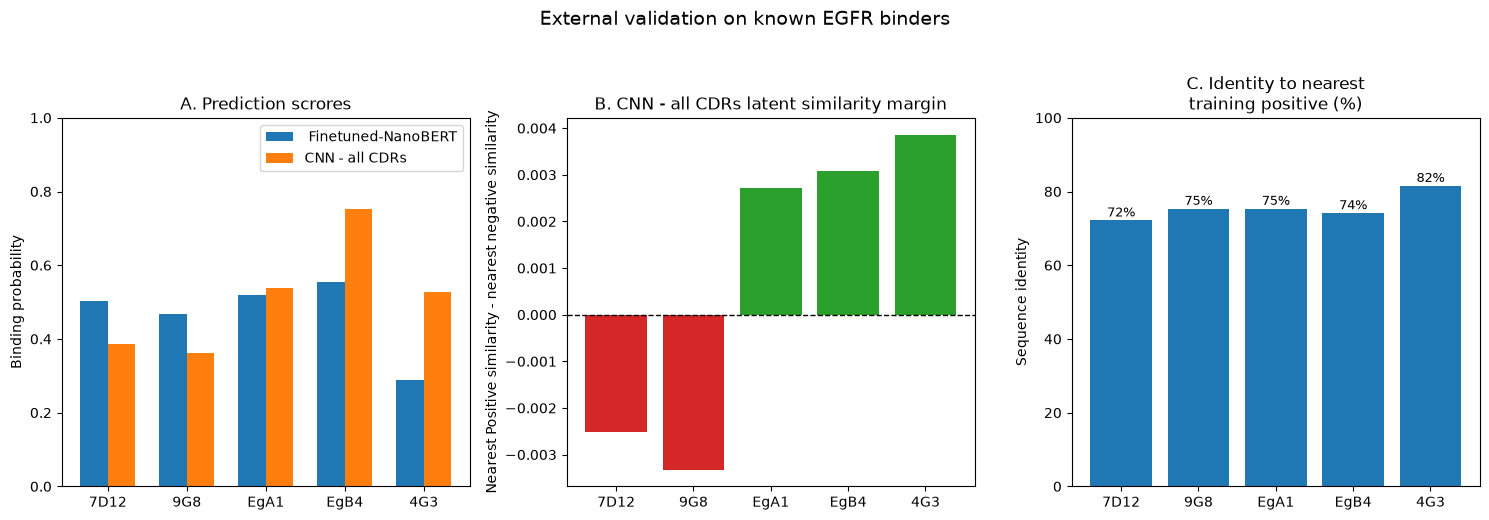

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(plot_summary_df))
width = 0.35

axes[0].bar(
    x - width / 2,
    plot_summary_df["External_NanoBERT_score"],
    width,
    label=" Finetuned-NanoBERT"
)

axes[0].bar(
    x + width / 2,
    plot_summary_df["External_CNN_score"],
    width,
    label="CNN - all CDRs"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_summary_df["Binder"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Binding probability")
axes[0].set_title("A. Prediction scrores")
axes[0].legend()

bar_colors = [
    "tab:red" if m < 0 else "tab:green"
    for m in plot_summary_df["Similarity_margin"]
]

axes[1].bar(
    plot_summary_df["Binder"],
    plot_summary_df["Similarity_margin"],
    color=bar_colors
)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Nearest Positive similarity - nearest negative similarity")
axes[1].set_title("B. CNN - all CDRs latent similarity margin")

axes[2].bar(
    plot_summary_df["Binder"],
    plot_summary_df["Sequence_identity_percent"]
)

axes[2].set_ylim(0, 100)
axes[2].set_ylabel("Sequence identity")
axes[2].set_title("C. Identity to nearest\ntraining positive (%)")

for i, val in enumerate(plot_summary_df["Sequence_identity_percent"]):
    axes[2].text(
        i,
        val + 1,
        f"{val:.0f}%",
        ha="center",
        fontsize=9
    )

plt.suptitle(
    "External validation on known EGFR binders",
    fontsize=14,
    y=1.03
)

plt.tight_layout()

plt.savefig(
    "external_egfr_binders_summary_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()